In [71]:
import numpy as np
import matplotlib.pyplot as plt

In [72]:
data = np.loadtxt('Daten_Frage_A.dat', delimiter='|')
time = data[:, 0]
Voltage = data[:, 1]

print(len(time))
print(time[-1] - time[0])
print(time[1] - time[0])
print(np.max(Voltage))
print(np.sum(Voltage) / len(Voltage))
print(np.std(Voltage, ddof=1))

2001
200.0
0.1
0.21990735817072385
0.1198835386926476
0.02533953707989825


In [73]:
def convert_time(t):

    """Diese Funktion konvertiert einen String, 

    der eine Uhrzeit im 24h-Format (bspw. 12:02 bzw. 15:58:15) darstellt, 

    in die Zahl der Sekunden, die seit 00:00:00 vergangen sind."""

    t = t.split(":")

    if len(t) == 2:

        return int(t[0])*3600 + int(t[1])*60

    else:

        return int(t[0])*3600 + int(t[1])*60 + int(t[2])



1-tes Moment vom ersten Datensatz: 25.0557
2-tes zentrales Moment vom ersten Datensatz: 9.111
3-tes zentrales Moment vom ersten Datensatz: 4.633


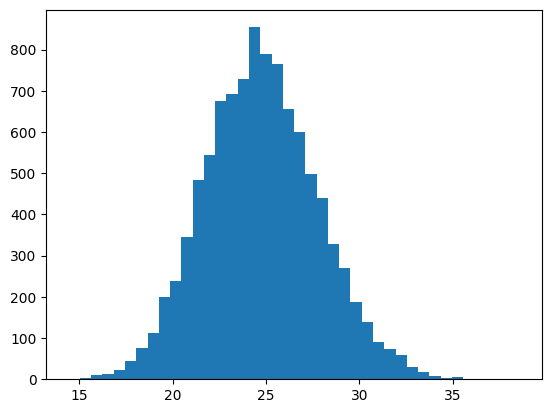

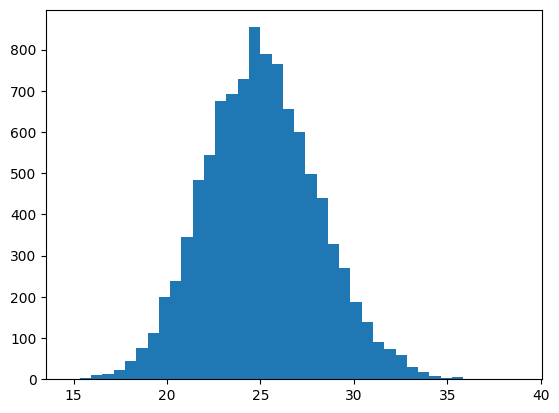

In [74]:
data = np.loadtxt('Daten_Frage_B2.txt', skiprows=1, delimiter=',')
t = data[:, 0]
x = data[:, 1]

def moment(data, n):
    return np.sum(data**n)/len(data)

m1 = moment(x, 1)

print(f'1-tes Moment vom ersten Datensatz: {m1:0.4f}')
for i in range(2):
    n = i+2
    mi_1 = moment(x-m1, n)
    print('{:n}-tes zentrales Moment vom ersten Datensatz: {:0.3f}'.format(n, mi_1))



counts, bin_edges = np.histogram(x, bins=40)
fig, ax = plt.subplots()
ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges))


fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.hist(x, bins=40);

0.003322455798081304
0.09993337774816789


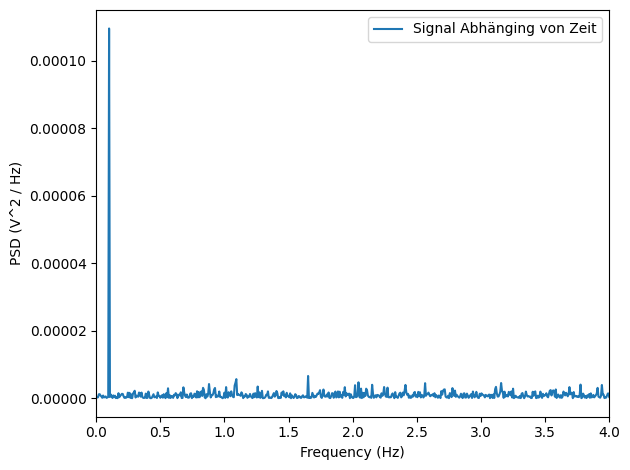

In [75]:
import numpy as np
from numpy.fft import fftfreq, fft, ifft
import matplotlib.pyplot as plt

data = np.loadtxt('Daten_Frage_C1.txt', delimiter='\t')
time_s = data[:, 0]
signal_V = data[:, 1]
sensor_noise_V = 0.1

print(np.std(signal_V, ddof=1))

# plt.plot(time_s, signal_V)

def plot_plot(*data_pairs, xlabel='x', ylabel='y', scale='linear', title='', xlim=None, ylim=None):
    fig = plt.figure()
    ax = fig.add_subplot(1, 1, 1)
    for pair in data_pairs:
        if len(pair) == 1:
            y, label = pair[0], ''
            x = np.arange(len(y))
        elif len(pair) == 2:
            y, label = pair[0], pair[1]
            x = np.arange(len(y))
        else:
            x, y, label = pair[0], pair[1], pair[2]
        yerr = pair[3] if len(pair) > 3 else None
        fmt = pair[4] if len(pair) > 4 else '-'
        ax.errorbar(x, y, yerr=yerr, fmt=fmt, capsize=5, label=label)
    
    if scale == 'logx':
        ax.set_xscale('log')
    elif scale == 'logy':
        ax.set_yscale('log')
    elif scale == 'loglog':
        ax.set_xscale('log')
        ax.set_yscale('log')
    
    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()

def compute_psd(signal, t, return_spectrum=False):
    dt = t[1] - t[0]
    N = len(t)
    frequency = fftfreq(N, d=dt)
    spectrum = fft(signal)
    psd = dt / N * np.abs(spectrum) ** 2
    mask = frequency >= 0
    if return_spectrum:
        return frequency[mask], psd[mask], spectrum
    return frequency[mask], psd[mask]

freq, psd = compute_psd(signal_V, time_s)

print(freq[np.argmax(psd)])

plot_plot(
    (freq, psd, 'Signal Abhänging von Zeit'),
    xlabel='Frequency (Hz)',
    ylabel='PSD (V^2 / Hz)',
    xlim=(0, 4)
)

0.0021929514435187238


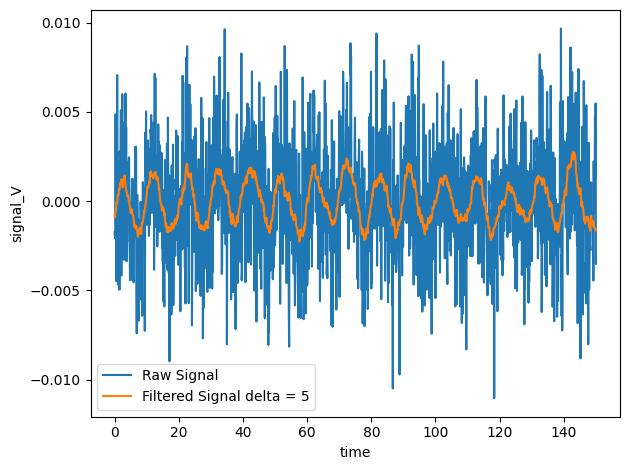

In [76]:
def moving_average(x, delta, edges='repeat'):
    N = len(x)

    filtered_array = np.zeros(N)

    if edges == 'repeat':
        padded_array = np.concatenate([np.ones(delta) * x[0], x, np.ones(delta) * x[-1]])
    elif edges == 'cut':
        padded_array = np.concatenate([np.zeros(delta), x, np.zeros(delta)])
    elif edges == 'wrap':
        padded_array = np.concatenate([x[-delta:], x, x[:delta]])
    else:
        raise ValueError("Invalid edge handling method. Choose 'repeat', 'cut', or 'wrap'.")
    
    for i in range(N):
        filtered_array[i] = np.mean(padded_array[i:i + 2 * delta])

    if edges == 'cut':
        return filtered_array[delta:-delta]
    
    return filtered_array

plot_plot(
    (time_s, signal_V, 'Raw Signal'),
    (time_s, moving_average(signal_V, 15), 'Filtered Signal delta = 5'),
    xlabel='time',
    ylabel='signal_V'
)

print(np.std(signal_V, ddof=1) - np.std(moving_average(signal_V, 15), ddof=1))

In [77]:
print((1500 / (time_s[-1] - time_s[0])) * 3)

30.0


In [78]:
data = np.loadtxt('Daten_Frage_D2.txt', skiprows=0, delimiter='\t')
t = data[:, 0]
T = data[:, 1]
m = data[:, 2]
k = []

for i in range(0, len(t)):
    k.append(m[i] * ((2 * np.pi) / T[i]) ** 2)


print(np.mean(T))
print(np.std(T)**2)

print(np.mean(m))
print(np.std(m)**2)

print(np.mean(k))
print(np.std(k)**2)

1.6001863590039571
0.007230846480334927
0.8057916862954384
0.01472770450571337
12.422336086714076
2.7057991993768162


14.544353229175812
-11.761031832605347
3.9892074237586597
-0.3398484346885166


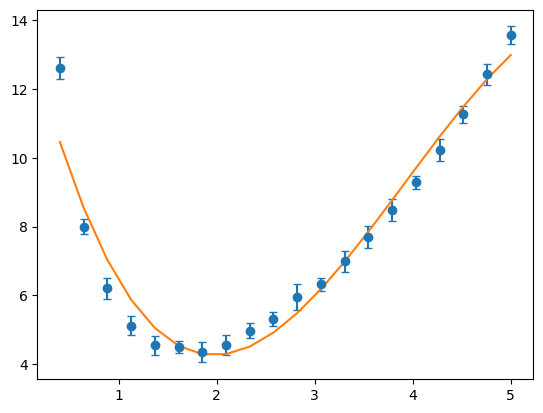

In [79]:
data = np.loadtxt('Daten_Frage_H1.txt', skiprows=1, delimiter=',')
x = data[:, 0]
y = data[:, 1]
sigma_y = data[:, 2]

a3, a2, a1, a0 = np.polyfit(x, y, 3, w=1/sigma_y)
print(a0)
print(a1)
print(a2)
print(a3)

t_fit = np.linspace(0, 5, 200)
plt.errorbar(x, y, sigma_y, fmt='o', capsize=3)
plt.plot(x, a0 + a1 * x + a2 * x**2 + a3 * x**3)
plt.show()

In [80]:
# Task 1: Read the data from data.csv
from sklearn.preprocessing import StandardScaler

# Hint: This one we already solved for you ;)
import pandas as pd
import numpy as np

df = pd.read_csv("data.csv")
display(df.head())

X = df.drop(['target'], axis=1)
y = df['target']

# Task 2: Split data into training and testing.

from sklearn.model_selection import train_test_split

# Hint: this function takes as parameter X, y, and a 'test_size' ;)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=41)
scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Task 3: Train a model on your data.

# Hint 1: Below are some options for models ;)
# Hint 2: To train a model, use the method 'fit' with some X and some y.
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# Task 4: Measure the quality of your estimator in the test data.

from sklearn.metrics import accuracy_score

# Hint: Here you use your estimator to 'predict' the labels for your
# test data.
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Hint: Call accuracy_score with the following arguments:
# 1. the true labels.
# 2. the labels you predicted.
accuracy_train = accuracy_score(y_train, y_pred_train)
accuracy_test = accuracy_score(y_test, y_pred_test)

print("Trainingsgenauigkeit: ", accuracy_train)
print("Testgenauigkeit:      ", accuracy_test)

# Task 5: Use your estimator to make predictions for the examples in X_final.csv

X_final = pd.read_csv("X_final.csv")
y_final =  model.predict(scaler.transform(X_final))
print(y_final)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,4.6,3.6,1.0,0.2,0
1,5.7,4.4,1.5,0.4,0
2,6.7,3.1,4.4,1.4,1
3,4.8,3.4,1.6,0.2,0
4,4.4,3.2,1.3,0.2,0


Trainingsgenauigkeit:  0.9880952380952381
Testgenauigkeit:       0.8888888888888888
[2 1 2 1 1 1 0 2 0 1]


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()

param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [5, 10, 15],
    "min_samples_split": [2, 10, 100]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

In [ ]:
import numpy as np

# Daten laden
x, y, sigma = np.loadtxt("data_regression.txt", unpack=True)

# Gewichtete lineare Regression
p, cov = np.polyfit(x, y, 1, w=1/sigma, cov=True)

m, c = p
dm, dc = np.sqrt(np.diag(cov))

print("m =", m)
print("c =", c)
print("Δm =", dm)
print("Δc =", dc)

In [ ]:
#kommt anders raus als im PDF, sollte aber richtig sein

# Task 1: Read the data from data.csv

# Hint: This one we already solved for you ;)
import pandas as pd
import numpy as np

titanic = pd.read_csv("Titanic.csv")

# Nur die geforderten Spalten + Target auswählen
features = ['Age', 'Pclass', 'Sex', 'SibSp', 'Parch']
target = ['Survived']

df = titanic[features + target].copy() #.copy() macht df unabhängig von titanic

# Aufteilen in X (Features) und y (Target)
X = df[features]
y = df[target]

# Task 2: Split data into training and testing.

from sklearn.model_selection import train_test_split

# Hint: this function takes as parameter X, y, and a 'test_size' ;)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=15)

# Task 3: Train a model on your data.

# Hint 1: Below are some options for models ;)
# Hint 2: To train a model, use the method 'fit' with some X and some y.
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

model = DecisionTreeClassifier(random_state=15)
model.fit(X_train, y_train)

# Task 4: Measure the quality of your estimator in the test data.

from sklearn.metrics import accuracy_score

# Hint: Here you use your estimator to 'predict' the labels for your
# test data.
y_pred =  model.predict(X_test)
# Hint: Call accuracy_score with the following arguments:
# 1. the true labels.
# 2. the labels you predicted.
acc = accuracy_score(y_test, y_pred)

print("Accuracy of classif. tree on test data: {:.3f}".format(acc))

# Task 5: Use your estimator to make predictions for the examples in X_final.csv

X_final = pd.read_csv("ToTest.csv")
X_final = X_final[features].copy()
y_final = model.predict(X_final)
print(y_final)
